## I. Các gói thư viện sử dụng

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub.*")

In [ ]:
!pip install python-dotenv huggingface_hub datasets WordCloud -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.6 MB/s eta 0:00:00


In [ ]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from dotenv import find_dotenv, load_dotenv
from huggingface_hub import login
from wordcloud import WordCloud

## II. Thiết lập môi trường làm việc
1. Kết nối google drive
2. Nạp biến môi trường từ .env
3. Kết nối Hugging Face

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
root_path = "/content/drive/MyDrive/BTL_AI_13_IT2302/AIWritingIndicator-13/SourceCode/"
%cd {root_path}
!pwd

/content/drive/.shortcut-targets-by-id/17JBaRqvfDFY0j8cN0vwu8kzqwtDISdDR/BTL_AI_13_IT2302/AIWritingIndicator-13/SourceCode
/content/drive/.shortcut-targets-by-id/17JBaRqvfDFY0j8cN0vwu8kzqwtDISdDR/BTL_AI_13_IT2302/AIWritingIndicator-13/SourceCode


In [7]:
env_path = find_dotenv()

if env_path:
    load_dotenv(env_path)
else:
    print("Không tìm thấy file .env!")

In [8]:
hf_token = os.getenv("HF_TOKEN")

if hf_token:
    login()
else:
    print("Không tồn tại env HF_TOKEN!")

## III. Trực quan hoá dữ liệu

### 1. Khám phá trực quan

In [9]:
df = pd.read_csv("Data/vietnamese_news_human_ai_eda.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Text                 10000 non-null  object 
 1   Label                10000 non-null  int64  
 2   char_count           10000 non-null  int64  
 3   word_count           10000 non-null  int64  
 4   sentence_count       10000 non-null  int64  
 5   ttr                  10000 non-null  float64
 6   number_count         10000 non-null  int64  
 7   capitalized_words    10000 non-null  int64  
 8   email_count          10000 non-null  int64  
 9   long_words_count     10000 non-null  int64  
 10  special_char_ratio   10000 non-null  float64
 11  caps_ratio           10000 non-null  float64
 12  missing_punctuation  10000 non-null  int64  
 13  segmented_text       10000 non-null  object 
 14  stopwords_ratio      10000 non-null  float64
 15  language             10000 non-null  

In [10]:
class DataVisualizer:
    def __init__(self, dataframe, label_col='Label', text_col='Text'):
        self.df = dataframe.copy()
        self.label_col = label_col
        self.text_col = text_col
        self.numeric_cols = self.df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        self.feature_cols = [col for col in self.numeric_cols if col != self.label_col]

    def plot_heatmap(self, method='pearson', figsize=(12, 8)):
        feature_df = self.df[self.feature_cols]
        corr_matrix = feature_df.corr(method=method)

        plt.figure(figsize=figsize)
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
                    vmin=-1, vmax=1, linewidths=0.5)

        plt.title(f"Biểu đồ nhiệt tương quan giữa các đặc trưng ({method.capitalize()} Correlation)")
        plt.tight_layout()
        plt.show()

    def plot_label_correlation(self, method='pearson', figsize=(10, 6)):
        if self.label_col not in self.numeric_cols:
            return

        corr_with_label = self.df[self.numeric_cols].corr(method=method)[self.label_col]
        corr_with_label = corr_with_label.drop(self.label_col)
        corr_with_label = corr_with_label.sort_values(ascending=False)
        plt.figure(figsize=figsize)
        sns.barplot(x=corr_with_label.values,
                    y=corr_with_label.index,
                    hue=corr_with_label.index,
                    palette='vlag',
                    legend=False)

        plt.title(f"Mức độ tương quan của các đặc trưng với Nhãn (Label: {self.label_col})")
        plt.xlabel(f"Hệ số tương quan {method.capitalize()}")
        plt.ylabel("Đặc trưng")
        plt.axvline(x=0, color='black', linestyle='--')
        plt.tight_layout()
        plt.show()

    def plot_histogram(self, feature, bins=30, figsize=(10, 6)):
        if feature not in self.numeric_cols:
            return

        plt.figure(figsize=figsize)
        sns.histplot(data=self.df, x=feature, hue=self.label_col, bins=bins, kde=True, palette='Set2')
        plt.title(f"Sự phân bố của {feature} (Histogram)")
        plt.xlabel(feature)
        plt.ylabel("Tần suất")
        plt.tight_layout()
        plt.show()

    def plot_boxplot(self, feature, figsize=(8, 6)):
        if feature not in self.numeric_cols:
            return

        plt.figure(figsize=figsize)
        sns.boxplot(data=self.df, x=self.label_col, y=feature, hue=self.label_col, palette='Set2', legend=False)
        plt.title(f"Mức độ phân tán và Outliers của {feature} (Box Plot)")
        plt.tight_layout()
        plt.show()

    def plot_scatter(self, feature_x, feature_y, figsize=(10, 6)):
        plt.figure(figsize=figsize)
        sns.scatterplot(data=self.df, x=feature_x, y=feature_y, hue=self.label_col, palette='Set2', alpha=0.7)
        plt.title(f"Mối quan hệ giữa {feature_x} và {feature_y}")
        plt.tight_layout()
        plt.show()

    def plot_wordcloud(self, figsize=(16, 8)):
        if self.text_col not in self.df.columns:
            return

        labels = self.df[self.label_col].unique()

        plt.figure(figsize=figsize)
        for i, label in enumerate(labels, 1):
            text_data = " ".join(self.df[self.df[self.label_col] == label][self.text_col].dropna().astype(str)).strip()

            if not text_data:
                continue

            try:
                wordcloud = WordCloud(width=800, height=400, background_color='white',
                                      colormap='viridis', max_words=100).generate(text_data)
            except ValueError:
                continue

            plt.subplot(1, len(labels), i)
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.title(f"Word Cloud - Label: {label}", fontsize=16)
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    def print_separator(self):
        print("\n")
        print("-" * 150)
        print("\n")

    def plot_all(self, hist_feature='word_count', box_feature='word_count', scatter_x='word_count', scatter_y='char_count', method='pearson'):
        self.plot_histogram(hist_feature)
        self.print_separator()

        self.plot_boxplot(box_feature)
        self.print_separator()

        self.plot_scatter(scatter_x, scatter_y)
        self.print_separator()

        self.plot_wordcloud()
        self.print_separator()

        self.plot_heatmap(method=method)
        self.print_separator()

        self.plot_label_correlation(method=method)

1. hist_feature = perplexity/burstiness/entropy/ttr/word_count/sentence_count
2. box_feature = perplexity/burstiness/entropy/noun_ratio/verb_ratio/adj_ratio/pronoun_ratio/stopwords_ratio/special_char_ratio/missing_punctuation
3. scatter_x = perplexity/burstiness/entropy/ttr/word_count/sentence_count noun_ratio/verb_ratio/adj_ratio

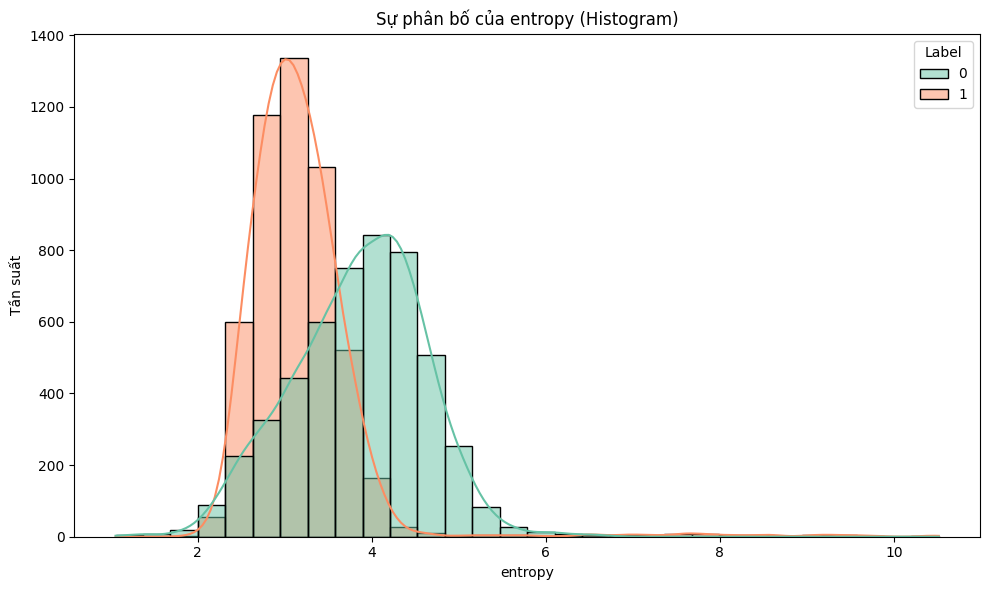



------------------------------------------------------------------------------------------------------------------------------------------------------




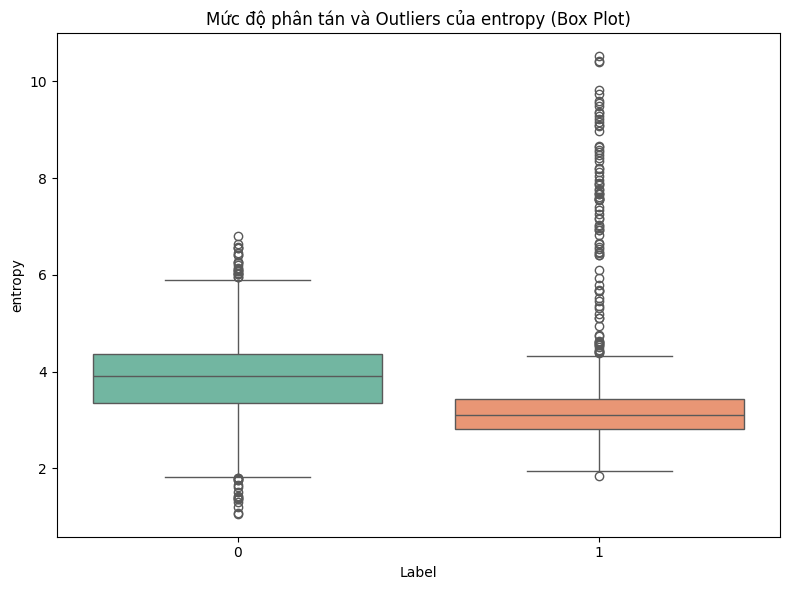



------------------------------------------------------------------------------------------------------------------------------------------------------




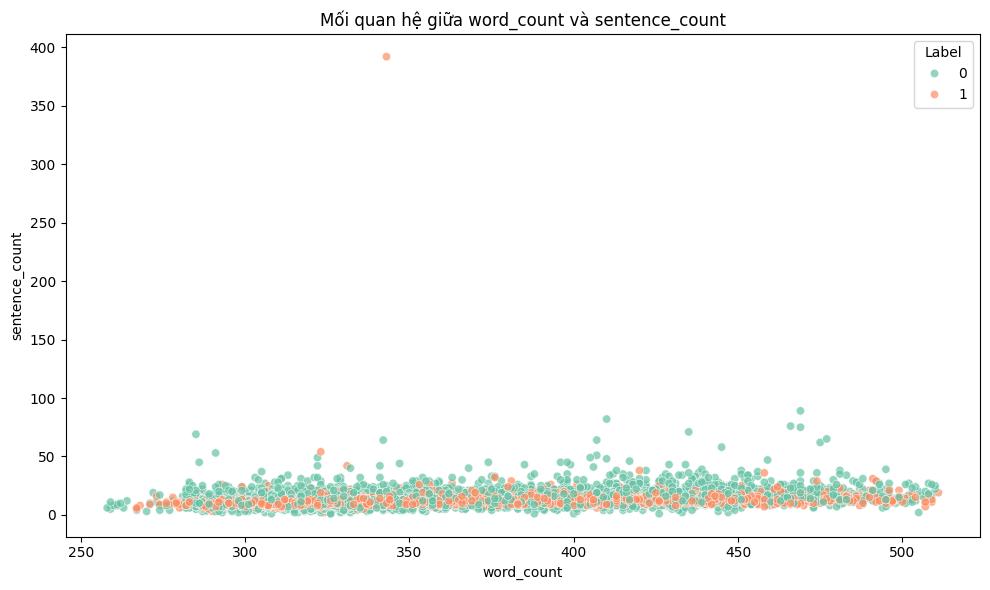



------------------------------------------------------------------------------------------------------------------------------------------------------




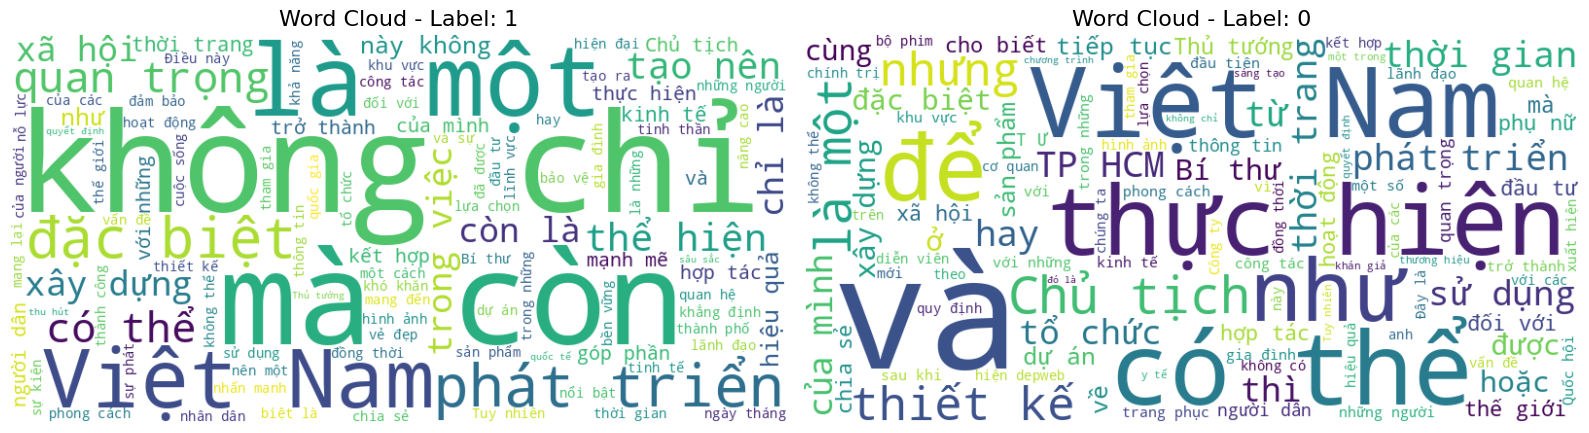



------------------------------------------------------------------------------------------------------------------------------------------------------




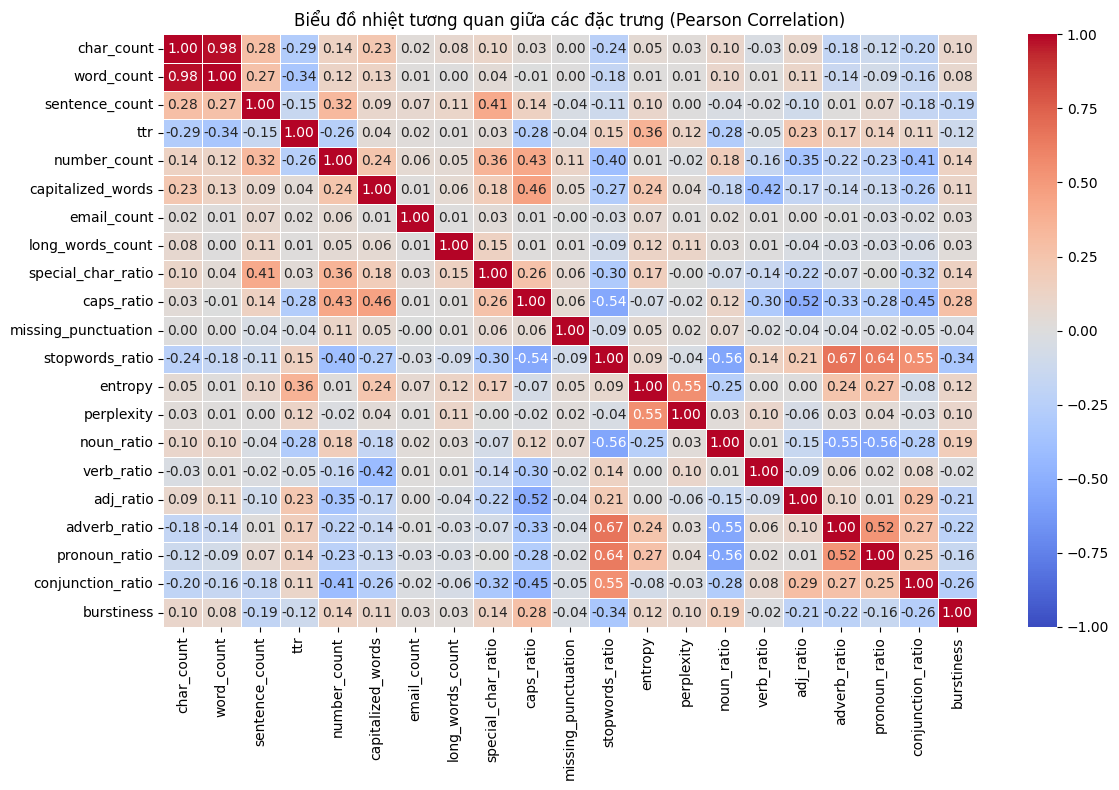



------------------------------------------------------------------------------------------------------------------------------------------------------




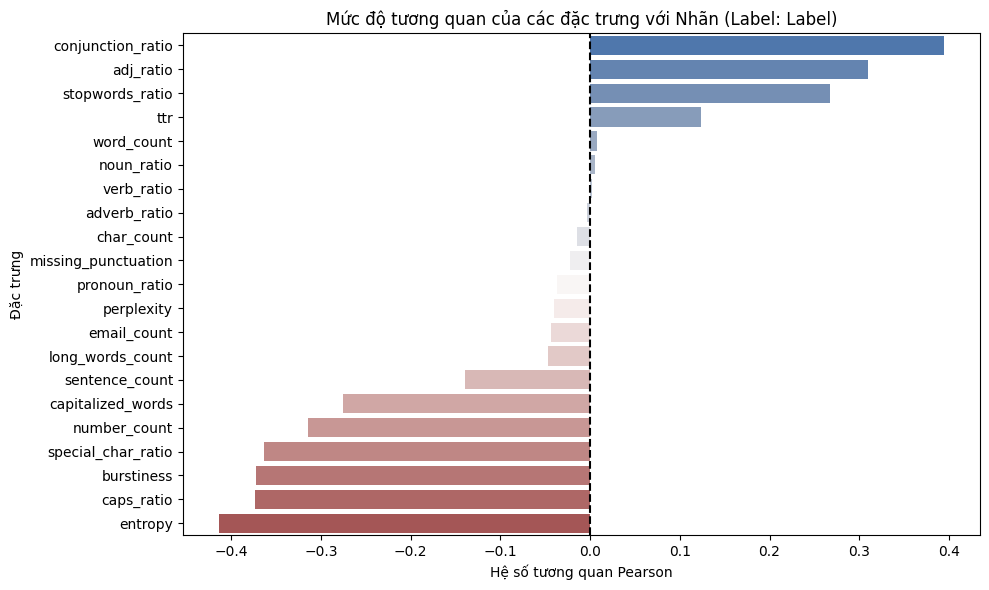

In [20]:
df = pd.read_csv("Data/vietnamese_news_human_ai_eda.csv")
analyzer = DataVisualizer(df, label_col='Label')
analyzer.plot_all(hist_feature='entropy', box_feature='entropy', scatter_x='word_count', scatter_y='sentence_count')

### 2. Trực quan báo cáo

In [13]:
class DataReportVisualizers:
    def __init__(self, dataframe=None, label_col='Label'):
        self.df = dataframe.copy() if dataframe is not None else None
        self.label_col = label_col

    def plot_feature_comparison(self, features, figsize=(10, 6)):
        if self.df is None or self.label_col not in self.df.columns:
            return

        grouped = self.df.groupby(self.label_col)[features].mean().reset_index()
        melted = grouped.melt(id_vars=self.label_col, var_name='Đặc trưng', value_name='Giá trị trung bình')

        plt.figure(figsize=figsize)
        sns.barplot(data=melted, x='Đặc trưng', y='Giá trị trung bình', hue=self.label_col, palette='Set2')
        plt.title("So sánh giá trị trung bình các đặc trưng giữa các nhãn")
        plt.xlabel("Đặc trưng")
        plt.ylabel("Giá trị trung bình")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_label_distribution(self, figsize=(8, 8)):
        if self.df is None or self.label_col not in self.df.columns:
            return

        counts = self.df[self.label_col].value_counts()

        plt.figure(figsize=figsize)
        plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
                colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})
        plt.title(f"Tỷ lệ phân bố của các nhãn (Label: {self.label_col})")
        plt.tight_layout()
        plt.show()


    def plot_all(self, comparison_features):
        self.plot_label_distribution()
        print("\n")
        self.plot_feature_comparison(comparison_features)


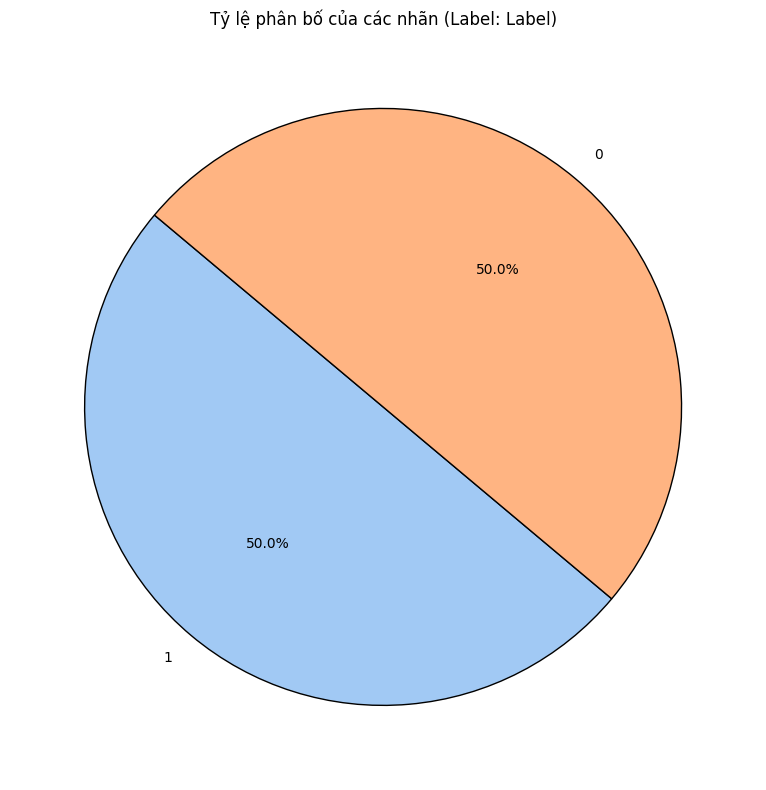

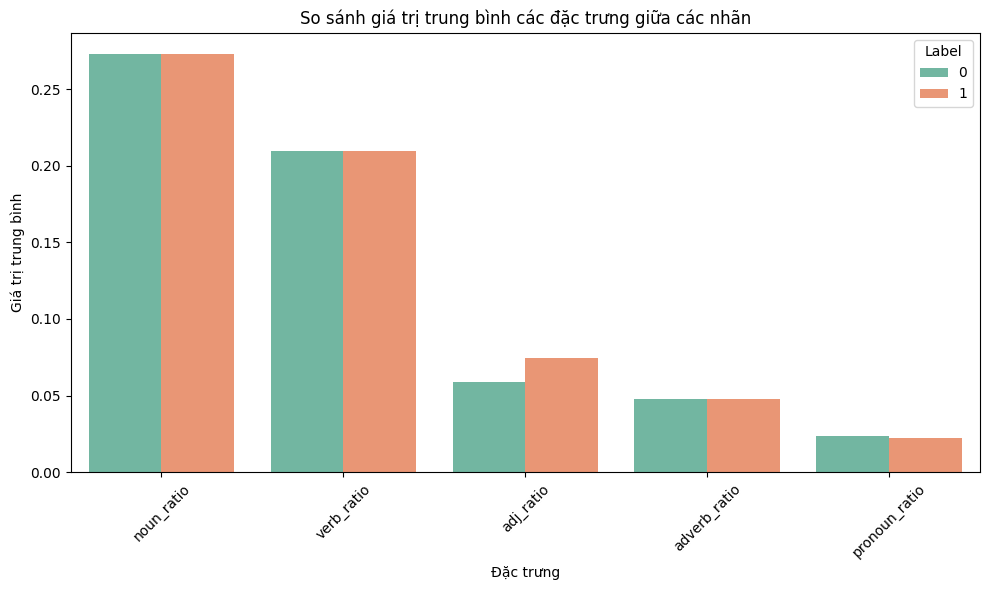

In [14]:
df = pd.read_csv("Data/vietnamese_news_human_ai_eda.csv")
reporter = DataReportVisualizers(df, label_col='Label')

pos_features = ['noun_ratio', 'verb_ratio', 'adj_ratio', 'adverb_ratio', 'pronoun_ratio']

reporter.plot_all(
    comparison_features=pos_features,
)